# To generate plots for Cliff Distance Prediction Case Study

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import pickle
from scipy.interpolate import make_interp_spline, PchipInterpolator

def find_cliff_hdist(df, threshold):
    """
    Identify the 'cliff' point in the data where the value drops significantly.
    The cliff is defined as the horizontal distance where the reliability first drops below the threshold.

    Parameters:
    df (pd.DataFrame): DataFrame for a combination of height, USI, and Bitrate. The columns are 'Horizontal_Distance' and 'Reliability'.
    threshold (float): The reliability threshold (e.g., 0.99).

    Returns:
    hdist: The horizontal distance of the cliff point (where reliability first drops below threshold).
           Returns 0 if no cliff is found or all values are below threshold.
    """
    # Sort by horizontal distance to find the first point where reliability drops below threshold
    df_sorted = df.sort_values('Horizontal_Distance').reset_index(drop=True)
    
    if df_sorted.empty:
        return 0
    
    # Find the first index where reliability drops below threshold
    below_threshold = df_sorted[df_sorted['Reliability'] < threshold]
    
    if below_threshold.empty:
        # No point drops below threshold, return the max horizontal distance
        return df_sorted['Horizontal_Distance'].max()
    
    # Return the horizontal distance of the first point below threshold
    return below_threshold['Horizontal_Distance'].iloc[0]

def find_cliff_hdist_spline_interp(df, threshold, k_points = 5):
    """
    Identify the 'cliff' point in the data where the value drops significantly.
    The cliff is defined as the horizontal distance where the reliability first drops below the threshold.
    Spline interpolation: We use spline interp to find the cliff point with a finer resolution of 1 m.
    Interpolation is first used to find the reliability at a resolution of 1 m before finding the cliff point.

    Parameters:
    df (pd.DataFrame): DataFrame for a combination of height, USI, and Bitrate. The columns are 'Horizontal_Distance' and 'Reliability'.
    threshold (float): The reliability threshold (e.g., 0.99).
    k_points (int): The number of nearest points to use for finding the reliability at finer resolution.

    Returns:
    hdist: The horizontal distance of the cliff point (where reliability first drops below threshold).
           Returns 0 if no cliff is found or all values are below threshold.
    """
    # Sort by horizontal distance to find the first point where reliability drops below threshold
    df_sorted = df.sort_values('Horizontal_Distance').reset_index(drop=True)
    
    if df_sorted.empty:
        return 0
    
    # Create a finer resolution of horizontal distances (1 m)
    hdist_fine = np.arange(df_sorted['Horizontal_Distance'].min(), df_sorted['Horizontal_Distance'].max() + 1, 1)
    # Interpolate reliability at finer resolution using k-nearest neighbors but only for the points not already in df_sorted
    for h in hdist_fine:
        if h in df_sorted['Horizontal_Distance'].values:
            pred = df_sorted[df_sorted['Horizontal_Distance'] == h]['Reliability'].values[0]
        else:
            # Find the k nearest points in df_sorted
            distances = np.abs(df_sorted['Horizontal_Distance'] - h)
            nearest_indices = np.argpartition(distances, kth=k_points - 1)[:k_points]
            nearest_reliabilities = df_sorted.loc[nearest_indices, 'Reliability']
            nearest_hdist = df_sorted.loc[nearest_indices, 'Horizontal_Distance']
            
            # Perform localized interpolation using the nearest points
            x_local = nearest_hdist.values
            y_local = nearest_reliabilities.values
            # Spline requires sorted x
            order = np.argsort(x_local)
            x_local = x_local[order]
            y_local = y_local[order]
            if len(x_local) == 1:
                pred = y_local[0]
            elif len(x_local) == 2:
                # Linear interpolation fallback
                pred = np.interp(float(h), x_local, y_local)
            else:
                # With 3 points, quadratic spline (k=2), else cubic spline (k=3)
                k = 2 if len(x_local) == 3 else 3
                spline = make_interp_spline(x_local, y_local, k=k)
                # Keep local behavior; avoid extrapolation outside local window
                h_eval = float(np.clip(h, x_local.min(), x_local.max()))
                pred = float(spline(h_eval))
        
        # If predicted reliability is less than threshold, we can stop early since we are only interested in the cliff point
        if pred < threshold:
            return h - 1  # Return the last horizontal distance before dropping below threshold
        
    #         reliability_fine.append(float(np.clip(pred, 0.0, 1.0)))  # Ensure reliability is between 0 and 1
    
    # df_fine = pd.DataFrame({'Horizontal_Distance': hdist_fine, 'Reliability': reliability_fine})

    # # Find the first index where reliability drops below threshold in the finer resolution
    # below_threshold = df_fine[df_fine['Reliability'] < threshold]
    
    # if below_threshold.empty:
    #     # No point drops below threshold, return the max horizontal distance
    #     return df_fine['Horizontal_Distance'].max()
    
    # # Return the horizontal distance of the first point below threshold
    # return below_threshold['Horizontal_Distance'].iloc[0]

def interp_reliability(df, k_points = 3):
    """
    Identify the 'cliff' point in the data where the value drops significantly.
    The cliff is defined as the horizontal distance where the reliability first drops below the threshold.
    Spline interpolation: We use spline interp to find the cliff point with a finer resolution of 1 m.
    Interpolation is first used to find the reliability at a resolution of 1 m before finding the cliff point.

    Parameters:
    df (pd.DataFrame): DataFrame for a combination of height, USI, and Bitrate. The columns are 'Horizontal_Distance' and 'Reliability'.
    threshold (float): The reliability threshold (e.g., 0.99).
    k_points (int): The number of nearest points to use for finding the reliability at finer resolution.

    Returns:
    hdist: The horizontal distance of the cliff point (where reliability first drops below threshold).
           Returns 0 if no cliff is found or all values are below threshold.
    """
    # Sort by horizontal distance to find the first point where reliability drops below threshold
    df_sorted = df.sort_values('Horizontal_Distance').reset_index(drop=True)
    
    if df_sorted.empty:
        return 0
    
    # Create a finer resolution of horizontal distances (1 m)
    hdist_fine = np.arange(df_sorted['Horizontal_Distance'].min(), df_sorted['Horizontal_Distance'].max() + 1, 1)
    # Interpolate reliability at finer resolution using k-nearest neighbors but only for the points not already in df_sorted
    reliability_fine = []
    for h in hdist_fine:
        if h in df_sorted['Horizontal_Distance'].values:
            pred = df_sorted[df_sorted['Horizontal_Distance'] == h]['Reliability'].values[0]
        else:
            # Find the k nearest points in df_sorted
            distances = np.abs(df_sorted['Horizontal_Distance'] - h)
            nearest_indices = np.argpartition(distances, kth=k_points - 1)[:k_points]
            nearest_reliabilities = df_sorted.loc[nearest_indices, 'Reliability']
            nearest_hdist = df_sorted.loc[nearest_indices, 'Horizontal_Distance']
            
            # Perform localized interpolation using the nearest points
            x_local = nearest_hdist.values
            y_local = nearest_reliabilities.values
            # Spline requires sorted x
            order = np.argsort(x_local)
            x_local = x_local[order]
            y_local = y_local[order]
            if len(x_local) == 1:
                pred = y_local[0]
            elif len(x_local) == 2:
                # Linear interpolation fallback
                pred = np.interp(float(h), x_local, y_local)
            else:
                # With 3 points, quadratic spline (k=2), else cubic spline (k=3)
                k = 2 if len(x_local) == 3 else 3
                spline = make_interp_spline(x_local, y_local, k=k)
                # Keep local behavior; avoid extrapolation outside local window
                h_eval = float(np.clip(h, x_local.min(), x_local.max()))
                pred = float(spline(h_eval))
        
        reliability_fine.append(float(np.clip(pred, 0.0, 1.0)))  # Ensure reliability is between 0 and 1
    
    df_fine = pd.DataFrame({'Horizontal_Distance': hdist_fine, 'Reliability': reliability_fine})
    return df_fine

In [ ]:
# Localized spline interpolation (4-NN) for cliff distance prediction
# For each USI + MCS + Height row, include Downlink/Uplink/Video GT and predictions
# Overall predicted cliff distance is the minimum predicted value across links

# -------------------------------------------------
# Assumes find_cliff_hdist(df, threshold) exists
# -------------------------------------------------

def add_reliability(df: pd.DataFrame) -> pd.DataFrame:
    if "Num_Sent" in df.columns and "Num_Reliable" in df.columns:
        df["Reliability"] = df["Num_Reliable"] / df["Num_Sent"]
    elif all(c in df.columns for c in ["Num_Fail_Other", "Num_Delay_Excd", "Num_Reliable"]):
        denom = df["Num_Reliable"] + df["Num_Delay_Excd"] + df["Num_Fail_Other"]
        df["Reliability"] = df["Num_Reliable"] / denom
    else:
        raise ValueError("Required columns for Reliability not found.")
    return df

def combo_subset(df: pd.DataFrame, usi: float, bitrate: float, height: float) -> pd.DataFrame:
    # isclose is safer than exact float equality
    m_usi = np.isclose(df["UAV_Sending_Interval"].to_numpy(dtype=float), float(usi))
    m_bitrate = np.isclose(df["Bitrate"].to_numpy(dtype=float), float(bitrate))
    m_height = np.isclose(df["Height"].to_numpy(dtype=float), float(height))
    return df.loc[m_usi & m_bitrate & m_height]

def local_spline_predict(train_heights, train_targets, test_height, k_neighbors=3):
    """
    Predict at test_height using a local spline fitted ONLY on k nearest train points.
    Returns np.nan if prediction cannot be made.
    """
    x = np.asarray(train_heights, dtype=float)
    y = np.asarray(train_targets, dtype=float)

    valid = np.isfinite(x) & np.isfinite(y)
    x, y = x[valid], y[valid]
    if x.size == 0:
        return np.nan

    # Deduplicate x if needed
    xy = (
        pd.DataFrame({"x": x, "y": y})
        .groupby("x", as_index=False)["y"]
        .mean()
        .sort_values("x")
    )
    x = xy["x"].to_numpy(dtype=float)
    y = xy["y"].to_numpy(dtype=float)

    n = min(int(k_neighbors), len(x))
    if n == 0:
        return np.nan

    # Pick k nearest points in height dimension
    dist = np.abs(x - float(test_height))
    idx = np.argpartition(dist, kth=n - 1)[:n]
    x_local = x[idx]
    y_local = y[idx]

    # Spline requires sorted x
    order = np.argsort(x_local)
    x_local = x_local[order]
    y_local = y_local[order]

    if len(x_local) == 1:
        pred = y_local[0]
    elif len(x_local) == 2:
        # Linear interpolation fallback
        pred = np.interp(float(test_height), x_local, y_local)
    else:
        # With 3 points, quadratic spline (k=2), else cubic spline (k=3)
        k = 2 if len(x_local) == 3 else 3
        spline = make_interp_spline(x_local, y_local, k=k)
        # Keep local behavior; avoid extrapolation outside local window
        h_eval = float(np.clip(test_height, x_local.min(), x_local.max()))
        pred = float(spline(h_eval))

    return float(max(pred, 0.0))  # optional clamp to non-negative

# -----------------------------
# Config
# -----------------------------
LINKS = ["Downlink", "Uplink", "Video"]
USI = [10, 20, 66.7, 100]
# USI = [20]
MCS = [6.5, 13, 19.5, 26, 39, 52, 58.5, 65]
TRAIN_HEIGHT = [60, 75, 90, 105, 120, 135, 150, 165, 180, 195, 210, 225, 240, 255, 270, 285, 300]
TEST_HEIGHT = [68, 82, 98, 112, 128, 142, 158, 172, 188, 202, 218, 232, 248, 262, 278, 292]
# TEST_HEIGHT = [98]
THRESHOLD = 0.99
K_NEIGHBORS = 4
CLIFF_THRESHOLD = 1  # Threshold for minimum cliff hdist to consider, in m

train_dataset_file_path = (
    f"C:\\Users\\reube\\OneDrive\\Documents\\PhD\\Journal2\\"
    f"Dataset_NP100000_DJISpark\\refined_train_0.1m_dataset_processed\\{{}}_Reliability.csv"
)
test_dataset_file_path = (
    f"C:\\Users\\reube\\OneDrive\\Documents\\PhD\\Journal2\\"
    f"Dataset_NP100000_DJISpark\\refined_test_0.1m_dataset_processed\\{{}}_Reliability.csv"
)

# -----------------------------
# Load and prepare data (per link)
# -----------------------------
train_df_by_link = {}
test_df_by_link = {}
for link in LINKS:
    train_df_by_link[link] = add_reliability(pd.read_csv(train_dataset_file_path.format(link)))
    test_df_by_link[link] = add_reliability(pd.read_csv(test_dataset_file_path.format(link)))

# Precompute training cliff curves per (Link, USI, MCS)
train_curves = {}
for link in LINKS:
    train_df = train_df_by_link[link]
    for usi in USI:
        for mcs in MCS:
            x_train = []
            y_train = []
            for h in TRAIN_HEIGHT:
                subset = combo_subset(train_df, usi, mcs, h)
                cliff_hdist = find_cliff_hdist(subset, threshold=THRESHOLD)
                x_train.append(float(h))
                y_train.append(float(cliff_hdist))

            x_train = np.array(x_train, dtype=float)
            y_train = np.array(y_train, dtype=float)

            # Exclude heights above the first near-zero cliff distance point
            low_cliff_indices = np.where(y_train <= CLIFF_THRESHOLD)[0]
            if low_cliff_indices.size > 0:
                low_cliff_height = x_train[low_cliff_indices[0]]
                print(
                    f"{link} | USI={usi}, MCS={mcs}: Excluding heights above {low_cliff_height} m "
                    f"due to low cliff distance (<= {CLIFF_THRESHOLD} m)."
                )
                mask = x_train < low_cliff_height
                x_train = x_train[mask]
                y_train = y_train[mask]

            if np.any(y_train > 0):
                train_curves[(link, usi, mcs)] = (x_train, y_train)

# -----------------------------
# Localized prediction on test (one row per USI, MCS, Height)
# Strict rule: skip combination unless ALL links are available and valid
# -----------------------------
results = []

for usi in USI:
    for mcs in MCS:
        # Skip this USI/MCS entirely if at least one link is missing from train_curves
        if not all((link, usi, mcs) in train_curves for link in LINKS):
            print(f"Skipping USI={usi}, MCS={mcs} because not all links are available in train_curves.")
            continue

        for h in TEST_HEIGHT:
            row = {
                "USI": usi,
                "MCS": mcs,
                "Bitrate": mcs,
                "Height": float(h),
            }

            predicted_by_link = {}
            gt_by_link = {}
            skip_row = False

            for link in LINKS:
                test_df = test_df_by_link[link]

                # Ground truth for this link
                subset_t = combo_subset(test_df, usi, mcs, h)
                gt = float(find_cliff_hdist(subset_t, threshold=THRESHOLD))
                row[f"{link} Ground Truth Cliff Hdist"] = gt
                gt_by_link[link] = gt

                # Prediction for this link
                x_train, y_train = train_curves[(link, usi, mcs)]

                # If this test height is outside valid train range for any link, skip combination
                if x_train.size == 0 or h > x_train.max():
                    skip_row = True
                    print(f"Skipping USI={usi}, MCS={mcs}, Height={h} because test height is outside valid train range for link={link}.")
                    break

                pred = local_spline_predict(
                    x_train,
                    y_train,
                    test_height=float(h),
                    k_neighbors=K_NEIGHBORS
                )

                # Strict NaN handling: if one link prediction is invalid, skip combination
                if not np.isfinite(pred):
                    skip_row = True
                    print(f"Skipping USI={usi}, MCS={mcs}, Height={h} because prediction is invalid for link={link}.")
                    break

                pred = float(pred)
                row[f"{link} Predicted Cliff Hdist"] = pred
                predicted_by_link[link] = pred

            if skip_row:
                continue

            row["Overall Predicted Cliff Hdist"] = float(np.min(list(predicted_by_link.values())))
            row["Overall Ground Truth Cliff Hdist"] = float(np.min(list(gt_by_link.values())))
            results.append(row)

results_df = pd.DataFrame(results)
if not results_df.empty:
    results_df = results_df.sort_values(["USI", "MCS", "Height"]).reset_index(drop=True)

print(f"Generated {len(results_df)} predictions.")
print(results_df.head())

Downlink | USI=10, MCS=6.5: Excluding heights above 60.0 m due to low cliff distance (<= 1 m).
Downlink | USI=10, MCS=13: Excluding heights above 60.0 m due to low cliff distance (<= 1 m).
Downlink | USI=10, MCS=39: Excluding heights above 285.0 m due to low cliff distance (<= 1 m).
Downlink | USI=10, MCS=52: Excluding heights above 165.0 m due to low cliff distance (<= 1 m).
Downlink | USI=10, MCS=58.5: Excluding heights above 150.0 m due to low cliff distance (<= 1 m).
Downlink | USI=10, MCS=65: Excluding heights above 165.0 m due to low cliff distance (<= 1 m).
Downlink | USI=20, MCS=6.5: Excluding heights above 60.0 m due to low cliff distance (<= 1 m).
Downlink | USI=20, MCS=39: Excluding heights above 285.0 m due to low cliff distance (<= 1 m).
Downlink | USI=20, MCS=52: Excluding heights above 180.0 m due to low cliff distance (<= 1 m).
Downlink | USI=20, MCS=58.5: Excluding heights above 150.0 m due to low cliff distance (<= 1 m).
Downlink | USI=20, MCS=65: Excluding heights ab

In [7]:
# Get all rows tied for the largest Overall Predicted Cliff Hdist
col = "Overall Predicted Cliff Hdist"

max_val = results_df[col].max(skipna=True)
largest_rows = results_df[results_df[col].eq(max_val)].copy()
largest_rows = largest_rows.sort_values(["USI", "MCS", "Height"]).reset_index(drop=True)

print(f"Largest {col}: {max_val}")
print(largest_rows)

Largest Overall Predicted Cliff Hdist: 484.4208395061727
     USI  MCS  Bitrate  Height  Downlink Ground Truth Cliff Hdist  \
0  100.0  6.5      6.5   292.0                              483.8   

   Downlink Predicted Cliff Hdist  Uplink Ground Truth Cliff Hdist  \
0                       484.42084                            507.5   

   Uplink Predicted Cliff Hdist  Video Ground Truth Cliff Hdist  \
0                    507.212948                           557.1   

   Video Predicted Cliff Hdist  Overall Predicted Cliff Hdist  \
0                   556.245156                      484.42084   

   Overall Ground Truth Cliff Hdist  
0                             483.8  


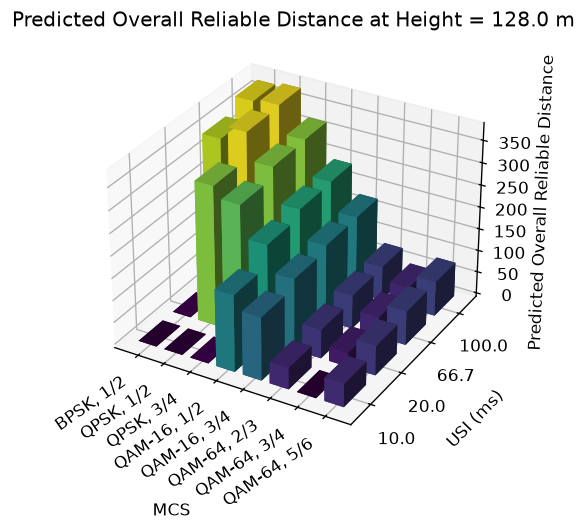

Pivot table used for plot:


MCS,6.5,13.0,19.5,26.0,39.0,52.0,58.5,65.0
USI,,,,,,,,
10.0,0.000000,0.000000,0.000000,173.013995,142.436948,48.493570,0.000000,52.224257
20.0,0.000000,315.934637,291.146716,220.176810,161.679951,65.426084,31.428672,66.780859
66.7,345.930301,376.473936,316.325501,237.393284,173.529807,76.007180,44.920198,76.674064
100.0,374.487822,380.904780,319.374449,239.916049,175.443664,77.404652,46.620504,78.307210


In [3]:
# 3D bar plot of Overall Predicted Cliff Hdist for one selected height
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (needed for 3D projection)

target_height = 128.0  # change this to any height in TEST_HEIGHT

# Always filter by a single height (future-proof when TEST_HEIGHT has multiple values)
df_h = results_df[np.isclose(results_df["Height"].astype(float), float(target_height))].copy()

# Build full USI-MCS grid so skipped combinations appear as 0
usi_values = sorted([float(u) for u in USI])
mcs_values = sorted([float(m) for m in MCS])

# Display labels for MCS (mapped from bitrate values)
mcs_label_map = {
    6.5: "BPSK, 1/2",
    13.0: "QPSK, 1/2",
    19.5: "QPSK, 3/4",
    26.0: "QAM-16, 1/2",
    39.0: "QAM-16, 3/4",
    52.0: "QAM-64, 2/3",
    58.5: "QAM-64, 3/4",
    65.0: "QAM-64, 5/6",
}
mcs_tick_labels = [mcs_label_map.get(float(v), str(v)) for v in mcs_values]

# If duplicates exist per (USI, MCS, Height), keep the max overall prediction
if not df_h.empty:
    agg = (
        df_h.groupby(["USI", "MCS"], as_index=False)["Overall Predicted Cliff Hdist"]
        .max()
    )
else:
    agg = pd.DataFrame(columns=["USI", "MCS", "Overall Predicted Cliff Hdist"])

pivot = agg.pivot(index="USI", columns="MCS", values="Overall Predicted Cliff Hdist")
pivot = pivot.reindex(index=usi_values, columns=mcs_values).fillna(0.0)

# Prepare 3D bar coordinates
x_idx = np.arange(len(mcs_values))
y_idx = np.arange(len(usi_values))
xx, yy = np.meshgrid(x_idx, y_idx)

x = xx.ravel()
y = yy.ravel()
z = np.zeros_like(x, dtype=float)
dz = pivot.to_numpy(dtype=float).ravel()

dx = np.full_like(x, 0.7, dtype=float)
dy = np.full_like(y, 0.7, dtype=float)

# Color bars by height value
if dz.max() > 0:
    colors = plt.cm.viridis(dz / dz.max())
else:
    colors = plt.cm.viridis(np.zeros_like(dz))

fig = plt.figure(figsize=(18, 5), dpi=120)
ax = fig.add_subplot(111, projection="3d")
ax.bar3d(x, y, z, dx, dy, dz, color=colors, shade=True)

ax.set_title(f"Predicted Overall Reliable Distance at Height = {target_height} m", fontsize=12, pad=0)
# fig.subplots_adjust(top=0.90)
ax.set_xlabel("MCS", labelpad=32)
ax.set_ylabel("USI (ms)", labelpad=12)
ax.set_zlabel("Predicted Overall Reliable Distance", labelpad=2)

ax.set_xticks(x_idx + 0.35)
ax.set_xticklabels(mcs_tick_labels, rotation=35, ha="right")
ax.set_yticks(y_idx + 0.35)
ax.set_yticklabels([str(v) for v in usi_values])

# Add extra spacing between tick labels and axes to reduce overlap
ax.xaxis.set_tick_params(pad=0)
ax.yaxis.set_tick_params(pad=6)

# plt.tight_layout()
fig.subplots_adjust(left=0.04, right=0.78, bottom=0.18, top=0.88)
plt.show()

# Optional: inspect the matrix used for plotting (zeros indicate skipped combinations)
print("Pivot table used for plot:")
display(pivot)

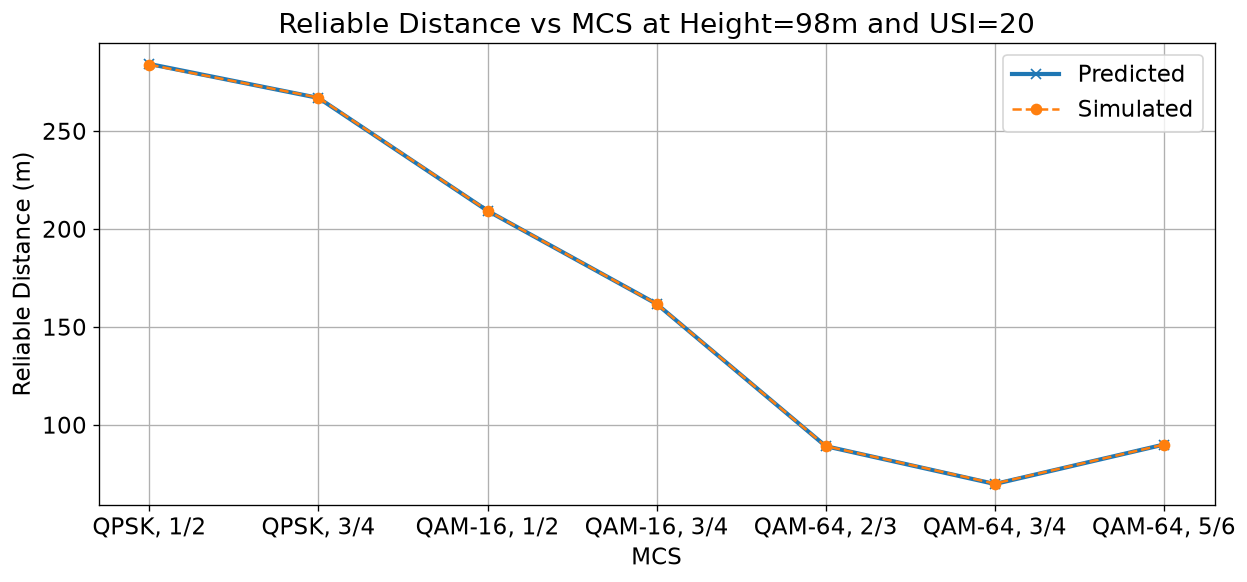

In [28]:
# Plot the cliff distance (ground truth vs predicted) vs MCS
plt.figure(figsize=(12, 5), dpi=120)
plt.rcParams.update({'font.size': 14})
# Display labels for MCS (mapped from bitrate values)
mcs_label_map = {
    6.5: "BPSK, 1/2",
    13.0: "QPSK, 1/2",
    19.5: "QPSK, 3/4",
    26.0: "QAM-16, 1/2",
    39.0: "QAM-16, 3/4",
    52.0: "QAM-64, 2/3",
    58.5: "QAM-64, 3/4",
    65.0: "QAM-64, 5/6",
}
mcs_tick_labels = [mcs_label_map.get(float(v), str(v)) for v in results_df["MCS"]]

plt.plot(
    mcs_tick_labels,
    results_df["Overall Predicted Cliff Hdist"],
    marker="x",
    linewidth=2.5,
    label="Predicted",
)
plt.plot(
    mcs_tick_labels,
    results_df["Overall Ground Truth Cliff Hdist"],
    "--o",
    label="Simulated",
)

plt.xlabel("MCS")
plt.ylabel("Reliable Distance (m)")
plt.title(f"Reliable Distance vs MCS at Height={TEST_HEIGHT[0]}m and USI={USI[0]}")
plt.legend()
plt.grid(True)
plt.show()

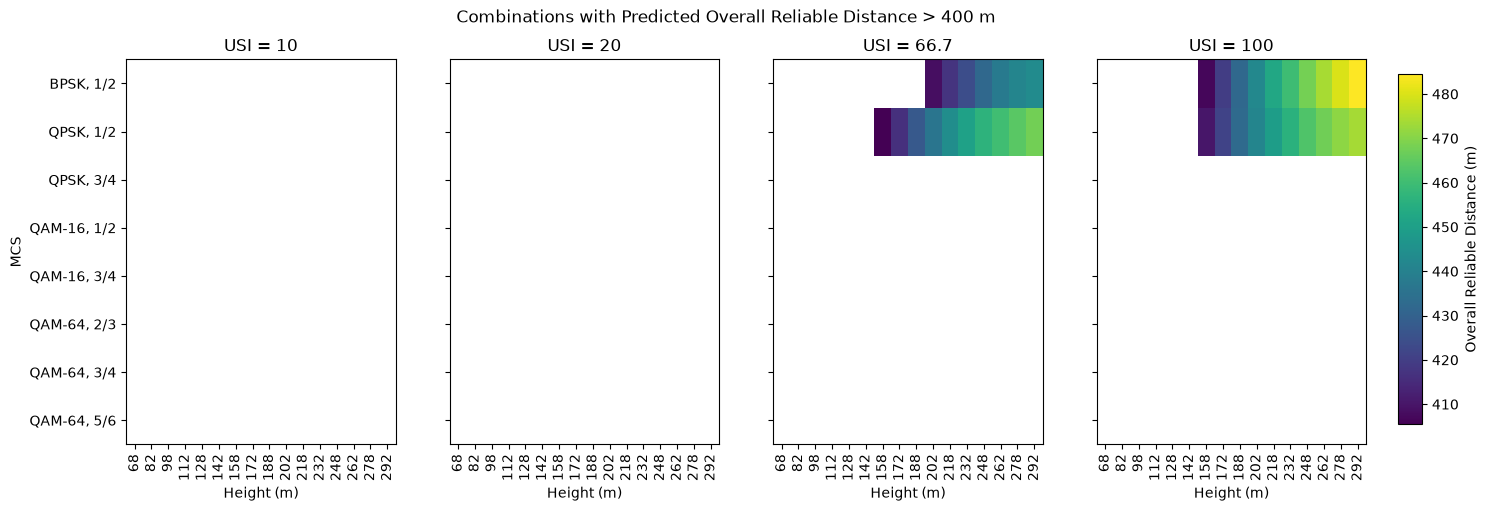

In [6]:
# Filter for cases where the overall predicted cliff distance is greater than a threshold (to find predictions that meet the threshold)
CLIFF_THRESHOLD_FILTER = 400  # in meters
filtered_df = results_df[results_df["Overall Predicted Cliff Hdist"] > CLIFF_THRESHOLD_FILTER].copy()

# Build the full grid of test combinations, keeping predicted value only where it exceeds the threshold
all_combos = pd.MultiIndex.from_product(
    [USI, MCS, TEST_HEIGHT], names=["USI", "MCS", "Height"]
).to_frame(index=False)

value_lookup = filtered_df.set_index(["USI", "MCS", "Height"])["Overall Predicted Cliff Hdist"]
all_combos["Value"] = all_combos.set_index(["USI", "MCS", "Height"]).index.map(value_lookup)

usi_values = sorted(USI)
mcs_values = sorted(MCS)
height_values = sorted(TEST_HEIGHT)

cmap = plt.cm.viridis.copy()
cmap.set_bad(color="white")  # NaN (below threshold / skipped) shows as empty

fig, axes = plt.subplots(1, len(usi_values), figsize=(4 * len(usi_values), 5), sharey=True)
vmin, vmax = all_combos["Value"].min(), all_combos["Value"].max()

mcs_label_map = {
    6.5: "BPSK, 1/2",
    13.0: "QPSK, 1/2",
    19.5: "QPSK, 3/4",
    26.0: "QAM-16, 1/2",
    39.0: "QAM-16, 3/4",
    52.0: "QAM-64, 2/3",
    58.5: "QAM-64, 3/4",
    65.0: "QAM-64, 5/6",
}

for ax, usi in zip(axes, usi_values):
    sub = all_combos[all_combos["USI"] == usi]
    pivot = (
        sub.pivot(index="MCS", columns="Height", values="Value")
        .reindex(index=mcs_values, columns=height_values)
    )
    masked = np.ma.masked_invalid(pivot.values.astype(float))
    im = ax.imshow(masked, aspect="auto", cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(f"USI = {usi}")
    ax.set_xticks(range(len(height_values)))
    ax.set_xticklabels(height_values, rotation=90)
    ax.set_yticks(range(len(mcs_values)))
    ax.set_yticklabels([mcs_label_map.get(m, m) for m in mcs_values])
    ax.set_xlabel("Height (m)")
axes[0].set_ylabel("MCS")

fig.subplots_adjust(right=0.9)
cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
fig.colorbar(im, cax=cbar_ax, label="Overall Reliable Distance (m)")

fig.suptitle(f"Combinations with Predicted Overall Reliable Distance > {CLIFF_THRESHOLD_FILTER} m")
plt.show()